Files already downloaded and verified


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


🚀 开始训练 PyTorch 版 Shallow GoogLeNet...
Epoch  1 | Train Acc: 0.3448 | Test Acc: 0.4418
Epoch  2 | Train Acc: 0.4655 | Test Acc: 0.5241
Epoch  3 | Train Acc: 0.5217 | Test Acc: 0.5723
Epoch  4 | Train Acc: 0.5559 | Test Acc: 0.6082
Epoch  5 | Train Acc: 0.5846 | Test Acc: 0.6208
Epoch  6 | Train Acc: 0.6054 | Test Acc: 0.6397
Epoch  7 | Train Acc: 0.6231 | Test Acc: 0.6376
Epoch  8 | Train Acc: 0.6340 | Test Acc: 0.6659
Epoch  9 | Train Acc: 0.6470 | Test Acc: 0.6817
Epoch 10 | Train Acc: 0.6612 | Test Acc: 0.6819
Epoch 11 | Train Acc: 0.6685 | Test Acc: 0.6937
Epoch 12 | Train Acc: 0.6747 | Test Acc: 0.6978
Epoch 13 | Train Acc: 0.6838 | Test Acc: 0.7055
Epoch 14 | Train Acc: 0.6943 | Test Acc: 0.7132
Epoch 15 | Train Acc: 0.7000 | Test Acc: 0.7199


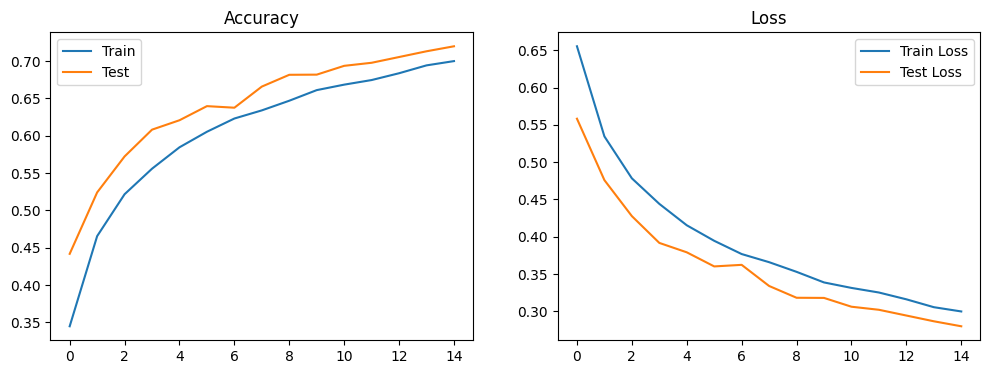


✅ 训练完成！模型已保存


In [1]:
# ==============================================
# shallow GoogLeNet - PyTorch 纯实现
# CIFAR10 图像分类（无 TensorFlow！）
# ==============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ====================== 1. 配置 ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs = 15
lr = 0.001

# ====================== 2. 数据加载 CIFAR10 ======================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ====================== 3. Inception 模块（GoogLeNet 核心） ======================
class InceptionModule(nn.Module):
    def __init__(self, in_channels, f1, f3, f5, pool_proj):
        super().__init__()
        # 1x1
        self.conv1 = nn.Conv2d(in_channels, f1, kernel_size=1, padding=0)
        # 3x3
        self.conv3 = nn.Conv2d(in_channels, f3, kernel_size=3, padding=1)
        # 5x5
        self.conv5 = nn.Conv2d(in_channels, f5, kernel_size=5, padding=2)
        # pool
        self.pool = nn.MaxPool2d(3, stride=1, padding=1)
        self.pool_conv = nn.Conv2d(in_channels, pool_proj, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out1 = self.relu(self.conv1(x))
        out2 = self.relu(self.conv3(x))
        out3 = self.relu(self.conv5(x))
        out4 = self.relu(self.pool_conv(self.pool(x)))
        return torch.cat([out1, out2, out3, out4], dim=1)

# ====================== 4. Shallow GoogLeNet 模型 ======================
class ShallowGoogLeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.inception1 = InceptionModule(64, 32, 64, 16, 16)
        self.inception2 = InceptionModule(32+64+16+16, 64, 128, 32, 32)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.avgpool = nn.AvgPool2d(8)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(64+128+32+32, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool2(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# ====================== 5. 初始化 ======================
model = ShallowGoogLeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# ====================== 6. 训练 ======================
train_acc_list = []
test_acc_list = []

print("🚀 开始训练 PyTorch 版 Shallow GoogLeNet...")
for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    for img, lab in train_loader:
        img, lab = img.to(device), lab.to(device)
        optimizer.zero_grad()
        out = model(img)
        loss = criterion(out, lab)
        loss.backward()
        optimizer.step()
        _, pred = out.max(1)
        total += lab.size(0)
        correct += pred.eq(lab).sum().item()
    train_acc = correct / total

    # 测试
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for img, lab in test_loader:
            img, lab = img.to(device), lab.to(device)
            out = model(img)
            _, pred = out.max(1)
            total += lab.size(0)
            correct += pred.eq(lab).sum().item()
    test_acc = correct / total

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# ====================== 7. 画图 ======================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_acc_list, label='Train')
plt.plot(test_acc_list, label='Test')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot([i for i in range(epochs)], [1-t for t in train_acc_list], label='Train Loss')
plt.plot([i for i in range(epochs)], [1-t for t in test_acc_list], label='Test Loss')
plt.legend()
plt.title('Loss')
plt.show()

# ====================== 8. 保存 ======================
torch.save(model.state_dict(), "shallow_googlenet_cifar10.pth")
print("\n✅ 训练完成！模型已保存")